# Почему «грязные» данные встречаются почти всегда?


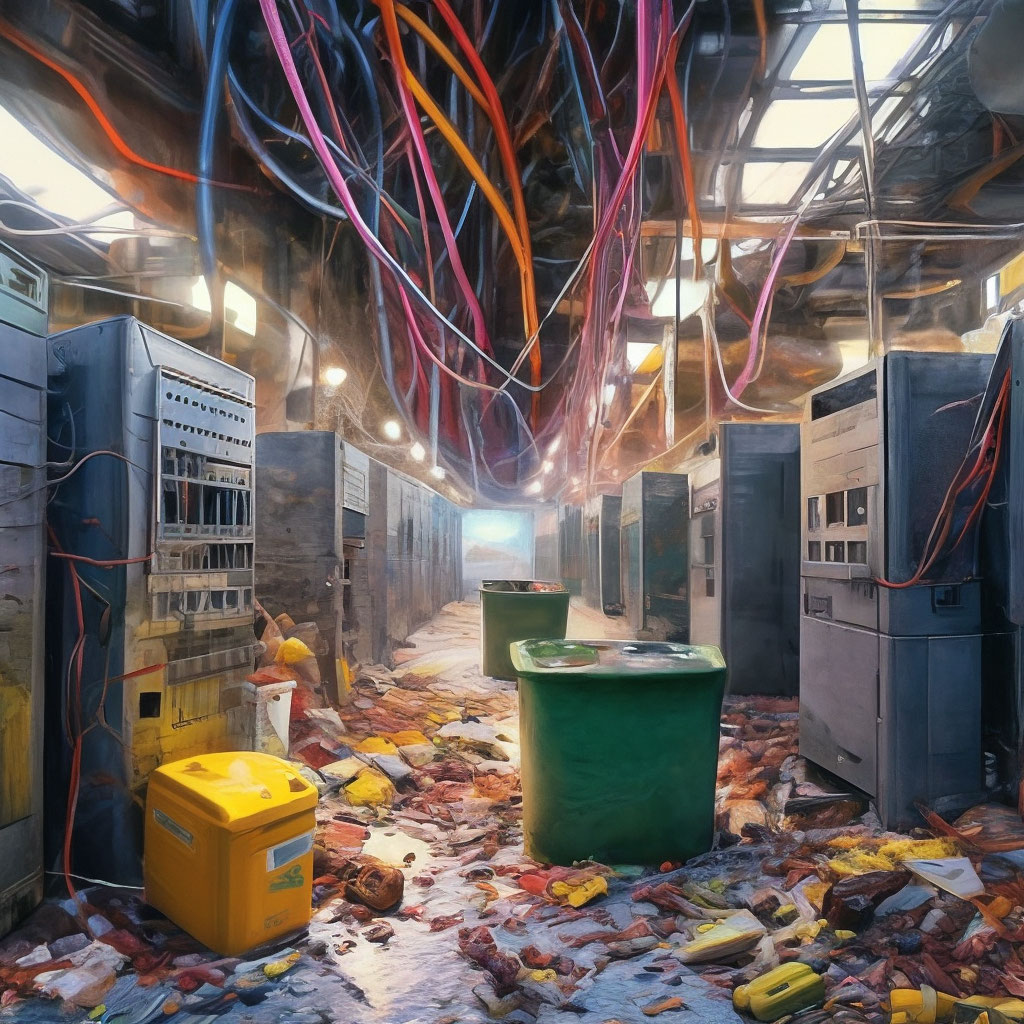

**Представьте ситуацию:**
- Вы получили данные от коллег
- Запустили анализ
- Получили странные результаты
- Потратили 2 дня на поиск ошибки

**А причина:**
- В одной колонке вместо чисел оказался текст
- 30% строк содержали пропуски
- Один и тот же город написан 5 разными способами

**Цель лекции**: Научиться правильно готовить данные для машинного обучения, чтобы избежать распространенных ошибок и улучшить качество моделей.

## Что может испортить анализ?

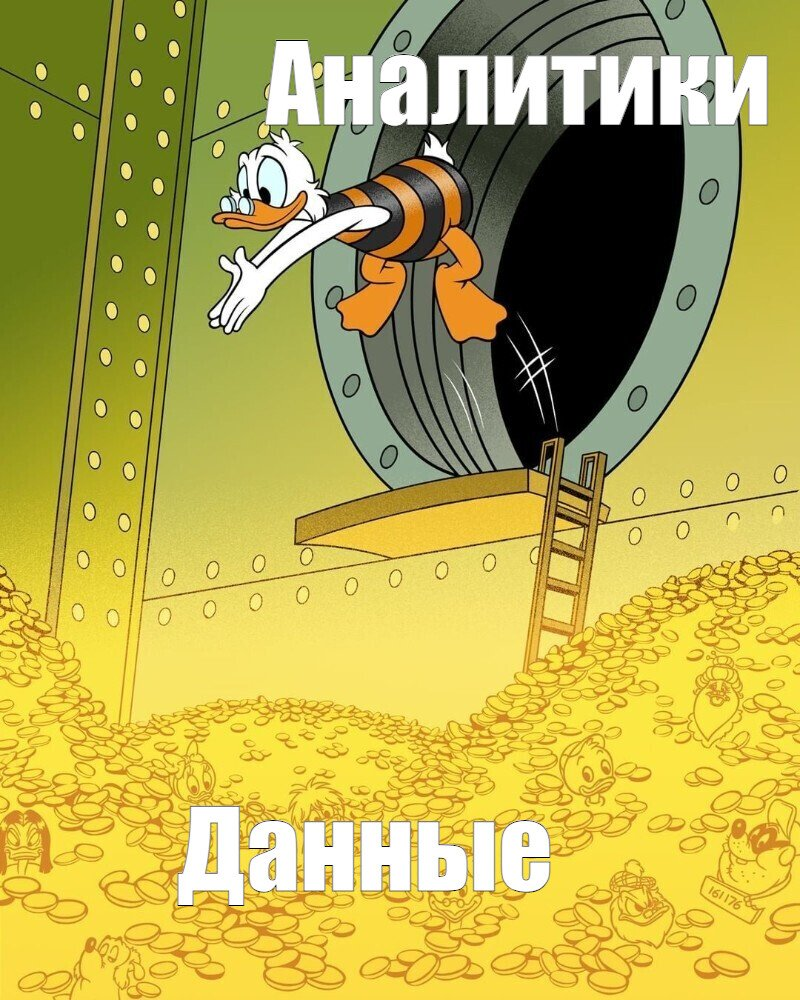

**Пропуски (Missing Values)**
   - Нет данных в важных колонках
   - Пример: у 20% студентов не указан GPA

**Дубликаты (Duplicates)**
   - Один и тот же объект записан несколько раз
   - Пример: один студент — 3 записи

**Выбросы (Outliers)**
   - Значения, сильно отличающиеся от остальных
   - Пример: возраст студента = 99 лет

**Разные написания (Inconsistent Data)**
   - Одна категория написана по-разному
   - Пример: "Москва", "Moscow", "г. Москва"

**Неверные типы данных**
   - Числа сохранены как текст
   - Пример: "25" вместо 25

## Наш инструментарий

# Что мы будем использовать?

**Python + Pandas**
   - Главный инструмент для работы с данными
   - Умеет читать CSV, JSON, XML, Excel
   - Мощные функции для очистки

**Google Sheets / Excel**
   - Быстрый просмотр данных
   - Визуальная проверка
   - Простые формулы

**JSON Viewer / XML Viewer**
   - Просмотр структуры вложенных данных
   - Понимание иерархии

**ChatGPT как консультант**
   - Помощь с формулами

### **CSV - самый простой формат**

student_id, faculty, year, gender, age, gpa

ST00001, CS, 1, Male, 18, 3.8

ST00002, Math, 2, Female, 19, 3.5

ST00003, Physics, 3, Male, 20, 4.0


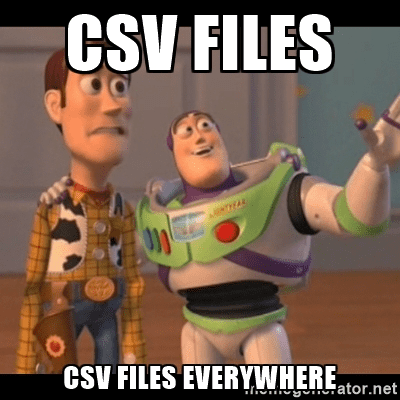

### **Проблемы CSV:**

* Разделители (запятая или точка с запятой?)

* Кодировка (UTF-8, Windows-1251?)

* Кавычки вокруг текста

Как открыть:

In [ ]:
import pandas as pd
df = pd.read_csv('/content/students.csv', encoding='utf-8')

df.head()

,student_id,faculty,year,gender,age,gpa,math_score,language_score,science_score,humanities_score,...,study_hours,part_time_work,scholarship,loan,sports,clubs,parent_education,income_level,distance_to_university,final_grade
0,ST01713,CS,3.0,Male,20.0,4.0,4.2,4.1,4.0,3.6,...,39.0,True,True,False,True,0.0,Master,High,11.4,4.4
1,ST01345,CS,1.0,Male,18.0,3.7,3.7,4.0,3.9,3.3,...,24.0,True,False,False,True,1.0,College,High,46.5,3.6
2,ST00846,Psychology,2.0,NaN,20.0,3.5,3.4,3.7,3.4,3.5,...,25.0,False,True,False,True,2.0,Master,Medium,27.1,3.7
3,ST00276,Biology,4.0,Male,21.0,3.3,3.3,2.9,3.5,3.5,...,29.0,False,False,False,False,0.0,College,High,33.6,3.1
4,ST00030,Psychology,2.0,Male,19.0,4.0,NaN,4.1,3.7,4.3,...,21.0,False,True,False,False,1.0,Bachelor,Medium,25.1,4.0


### **JSON - иерархия и вложенность**

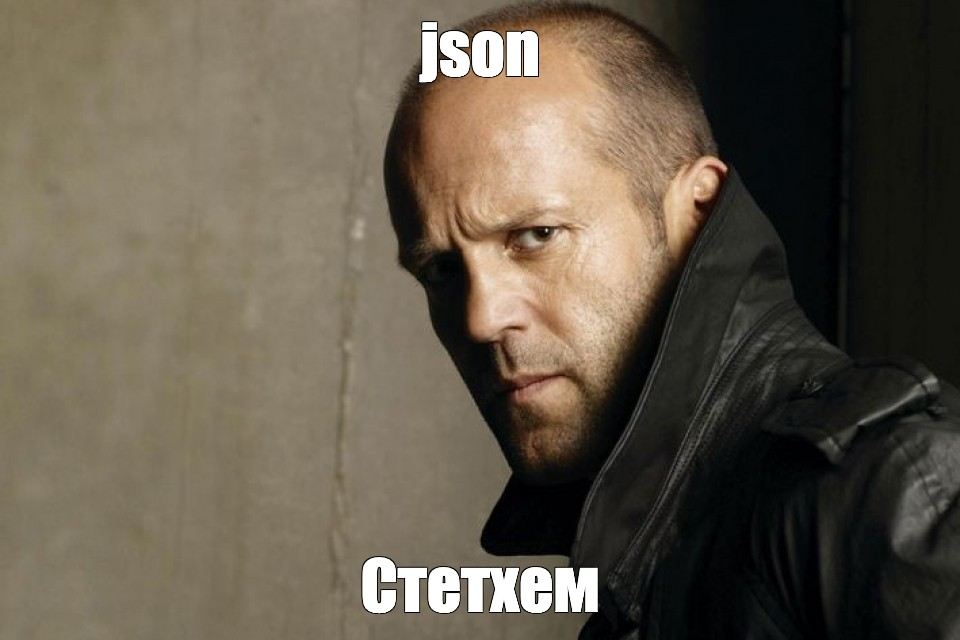

```
{
  "catalogs": [
    {
      "conditions": "Предложения действительны для Москвы, Переславль-Залесского и Костромской области. Информацию об ассортименте товаров, участвующих в акции, уточняйте в магазине. Количество товаров ограничено, не является публичной офертой.",
      "date_end": "2020-06-12",
      "date_start": "2020-06-05",
      "id": "1234",
      "image": "https://retailer1234.ru/catalogs/1234.jpg",
      "is_main": true,
      "offers": [
        "11111",
        "22222",
        "33333"
      ],
      "target_regions": [
        "Россия, Москва",
        "Россия, Ярославская область, Переславль-Залесский",
        "Россия, Костромская область, Островский район, село Адищево"
      ]
    },
    ....
```

### **Проблемы JSON:**

* Сложная структура

* Много вложенности

* Большой размер

### **Как открыть:**

In [ ]:
import json
with open('example.json') as f:
    data = json.load(f)


print(data)

{'catalogs': [{'conditions': 'Предложения действительны для Москвы, Переславль-Залесского и Костромской области. Информацию об ассортименте товаров, участвующих в акции, уточняйте в магазине. Количество товаров ограничено, не является публичной офертой.', 'date_end': '2020-06-12', 'date_start': '2020-06-05', 'id': '1234', 'image': 'https://retailer1234.ru/catalogs/1234.jpg', 'is_main': True, 'offers': ['11111', '22222', '33333'], 'target_regions': ['Россия, Москва', 'Россия, Ярославская область, Переславль-Залесский', 'Россия, Костромская область, Островский район, село Адищево']}, {'conditions': 'Предложения действительны в магазине по адресу: Владимир, улица Куйбышева, 26К', 'date_end': '2020-06-12', 'date_start': '2020-06-05', 'id': '5678', 'image': 'https://retailer1234.ru/catalogs/1234.jpg', 'is_main': True, 'offers': ['22222', '33333'], 'target_shops': ['Владимир, улица Куйбышева, 26К']}], 'offers': [{'barcode': '7501031311309', 'date_end': '2020-06-10', 'date_start': '2020

In [ ]:
print(json.dumps(data, indent=2))

{
  "catalogs": [
    {
      "conditions": "\u041f\u0440\u0435\u0434\u043b\u043e\u0436\u0435\u043d\u0438\u044f \u0434\u0435\u0438\u0306\u0441\u0442\u0432\u0438\u0442\u0435\u043b\u044c\u043d\u044b \u0434\u043b\u044f \u041c\u043e\u0441\u043a\u0432\u044b, \u041f\u0435\u0440\u0435\u0441\u043b\u0430\u0432\u043b\u044c-\u0417\u0430\u043b\u0435\u0441\u0441\u043a\u043e\u0433\u043e \u0438 \u041a\u043e\u0441\u0442\u0440\u043e\u043c\u0441\u043a\u043e\u0438\u0306 \u043e\u0431\u043b\u0430\u0441\u0442\u0438. \u0418\u043d\u0444\u043e\u0440\u043c\u0430\u0446\u0438\u044e \u043e\u0431 \u0430\u0441\u0441\u043e\u0440\u0442\u0438\u043c\u0435\u043d\u0442\u0435 \u0442\u043e\u0432\u0430\u0440\u043e\u0432, \u0443\u0447\u0430\u0441\u0442\u0432\u0443\u044e\u0449\u0438\u0445 \u0432 \u0430\u043a\u0446\u0438\u0438, \u0443\u0442\u043e\u0447\u043d\u044f\u0439\u0442\u0435 \u0432 \u043c\u0430\u0433\u0430\u0437\u0438\u043d\u0435. \u041a\u043e\u043b\u0438\u0447\u0435\u0441\u0442\u0432\u043e \u0442\u043e\u0432\u0430\u0440

In [ ]:
data['offers'][0]['price_new']

50

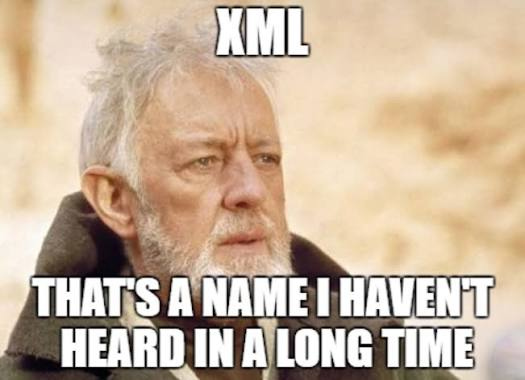

### **XML - старый, но живой**



```
<students>
  <student id="ST00001">
    <name>Ivanov Ivan</name>
    <faculty>CS</faculty>
    <grades>
      <math>4.5</math>
      <physics>4.0</physics>
    </grades>
  </student>
</students>
...
```



### **Проблемы XML:**

* Много тегов (раздутый)

* Сложно парсить

* Устаревающий

Как открыть:

In [ ]:
import xml.etree.ElementTree as ET
tree = ET.parse('/content/example.xml')
root = tree.getroot()

Посмотрим на корневой элемент

In [ ]:
print(f"Корневой элемент: {root.tag}")
print(f"Атрибуты корневого элемента: {root.attrib}")

Корневой элемент: PurchaseOrder
Атрибуты корневого элемента: {'PurchaseOrderNumber': '99503', 'OrderDate': '1999-10-20'}


Достанем дочерний элемент

In [ ]:
delivery_notes = root.find('DeliveryNotes')
if delivery_notes is not None:
    print(f"Примечания: {delivery_notes.text}")

Примечания: Please leave packages in shed by driveway.


## CSV vs JSON vs XML

| Характеристика | CSV | JSON | XML |
|----------------|-----|------|-----|
| **Читаемость** | отличная | хорошая | ужасная |
| **Вложенность** | нет | да | да |
| **Размер** | Маленький | Средний | Большой |
| **Скорость** | Быстрый | Средний | Медленный |
| **Использование** | Таблицы | API, конфиги | Старые системы |

# 3 ключевых принципа работы с данными:

**INSPECT (Изучи)**
   - Посмотри на структуру
   - Найди проблемы
   - Оцени масштаб

**CLEAN (Очисти)**
   - Заполни пропуски
   - Удали дубликаты
   - Исправь форматы

**COMPARE (Сравни)**
   - Проверь, стало лучше?
   - Сравни статистики
   - Визуализируй изменения

# Часть 1. Работа с пропусками


| № |	Название колонки (англ.) |	Название колонки (рус.) |	Тип данных |	Описание |
|---|-----|----|----|-----|
| 1	| student_id |	ID студента|	String |	Уникальный идентификатор студента  (формат: ST00001)|
|2|	faculty|	Факультет|	String|	Название факультета (CS, Mathematics, Physics, Biology, Chemistry, Economics, Psychology, Law, History, Languages)|
| 3|	year |	Курс |	Integer |	Год обучения (1-4)
|4|	gender |	Пол |	String |	Пол студента (Male/Female)
|5|	age |	Возраст |	Integer |	Возраст студента (от 18 до 60 лет)
|6|	gpa |	Средний балл	 | Float |	Grade Point Average - средний балл успеваемости (от 2.0 до 5.0)
|7|	math_score |	Оценка по математике |	Float |	Оценка по математике (от 2.0 до 5.0)
|8|	language_score |	Оценка по языку |	Float |	Оценка по иностранному языку (от 2.0 до 5.0)
|9|	science_score |	Оценка по естественным наукам |	Float |	Оценка по естественным наукам (от 2.0 до 5.0)
|10|	humanities_score |	Оценка по гуманитарным наукам |	Float |	Оценка по гуманитарным наукам (от 2.0 до 5.0)
|11|	attendance |	Посещаемость |	Float |	Процент посещаемости занятий (от 0.5 до 1.0, т.е. 50%-100%)
|12|	study_hours |	Часы учебы |	Integer |	Количество часов учебы в неделю (от 10 до 40)
|13|	part_time_work |	Подработка |	Boolean |	Работает ли студент (True/False)
|14|	scholarship |	Стипендия |	Boolean |	Получает ли стипендию (True/False)
|15|	loan |	Кредит |	Boolean |	Есть ли образовательный кредит (True/False)
|16|	sports |	Спорт |	Boolean	| Занимается ли спортом (True/False)
|17|	clubs |	Клубы |	Integer |	Количество студенческих клубов, в которых состоит (0-3)
|18|	parent_education |	Образование родителей |	String |	Уровень образования родителей (School, College, Bachelor, Master, PhD)
|19|	income_level |	Уровень дохода |	String |	Уровень дохода семьи (Low, Medium, High)
|20|	distance_to_university |	Расстояние до университета |	Float	 | Расстояние от дома до университета в километрах (1-50)
|21|	final_grade	 | Итоговая оценка |	Float |	Итоговая оценка за семестр (от 2.0 до 5.0)

Почему пропуски - это проблема?

In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv("/content/students.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2093 entries, 0 to 2092
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              2090 non-null   object 
 1   faculty                 2090 non-null   object 
 2   year                    2090 non-null   float64
 3   gender                  2035 non-null   object 
 4   age                     2029 non-null   float64
 5   gpa                     2038 non-null   float64
 6   math_score              2028 non-null   float64
 7   language_score          2046 non-null   float64
 8   science_score           2039 non-null   float64
 9   humanities_score        2042 non-null   float64
 10  attendance              2007 non-null   float64
 11  study_hours             2077 non-null   float64
 12  part_time_work          2074 non-null   object 
 13  scholarship             2091 non-null   object 
 14  loan                    2012 non-null   

Проблемы:
1. Большинство алгоритмов ML не работает с NaN
2. Пропуски искажают статистики
3. Могут указывать на важную информацию

## УДАЛЕНИЕ СТРОК И СТОЛБЦОВ С ПРОПУСКАМИ

## простые методы стратегии:

### 1. Удаление (самый простой, но не всегда самый лучший способ)

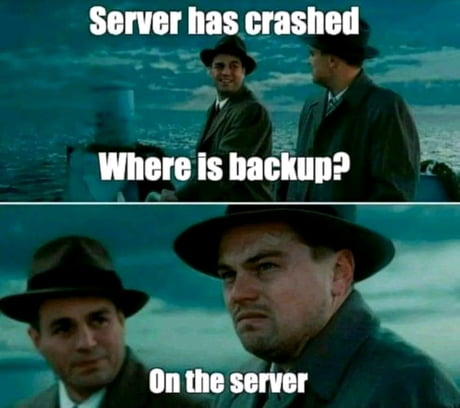

In [ ]:
# Удаление строк с любыми пропусками
data_dropped = data.dropna()
data_dropped

,student_id,faculty,year,gender,age,gpa,math_score,language_score,science_score,humanities_score,...,study_hours,part_time_work,scholarship,loan,sports,clubs,parent_education,income_level,distance_to_university,final_grade
0,ST01713,CS,3.0,Male,20.0,4.0,4.2,4.1,4.0,3.6,...,39.0,True,True,False,True,0.0,Master,High,11.4,4.4
1,ST01345,CS,1.0,Male,18.0,3.7,3.7,4.0,3.9,3.3,...,24.0,True,False,False,True,1.0,College,High,46.5,3.6
3,ST00276,Biology,4.0,Male,21.0,3.3,3.3,2.9,3.5,3.5,...,29.0,False,False,False,False,0.0,College,High,33.6,3.1
7,ST01570,Psychology,1.0,Male,18.0,3.5,3.3,3.5,3.8,3.4,...,25.0,True,False,False,False,0.0,College,Low,14.9,3.6
8,ST01706,Chemistry,2.0,Male,20.0,3.2,3.2,3.0,3.5,3.3,...,26.0,False,False,False,False,2.0,Master,High,44.0,3.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2086,ST01239,Physics,3.0,Male,23.0,3.1,3.3,2.9,3.3,3.0,...,20.0,False,False,False,False,0.0,School,Low,35.5,3.1
2087,ST00467,Chemistry,1.0,Male,18.0,3.6,3.9,3.3,3.5,3.6,...,12.0,False,True,False,True,2.0,Bachelor,Low,1.9,3.7
2090,ST01131,Physics,3.0,Female,22.0,3.9,3.9,3.8,4.2,3.7,...,18.0,False,False,False,False,1.0,Master,High,12.0,3.9
2091,ST01295,Economics,3.0,Female,20.0,3.6,3.4,3.5,3.7,3.7,...,16.0,False,False,False,False,0.0,Bachelor,Medium,21.6,3.7


### Удаление столбцов с >10% пропусков

In [ ]:

threshold = len(data) * 0.10
df_dropped_cols = data.dropna(thresh=threshold, axis=1)

# thresh=threshold - минимальное количество НЕпропущенных значений,
# которое должно быть в строке/столбце
# axis=0 это по столбцам, axis=1 - по строкам

print(f"Размер до удаления столбцов: {data.shape}")
print(f"Размер после удаления: {df_dropped_cols.shape}")
print(f"Удалено столбцов: {data.shape[1] - df_dropped_cols.shape[1]}")

Размер до удаления столбцов: (2093, 21)
Размер после удаления: (2093, 21)
Удалено столбцов: 0


Когда использовать:
1. Пропусков очень мало (< 5%-10%)
2. Данных достаточно много
3. Пропуски не значительны, не являются важными

### Удаляем строки с пропусками только в важных колонках

In [ ]:
important_cols = ['gpa', 'final_grade', 'attendance', 'study_hours']
df_dropped_important = data.dropna(subset=important_cols)

print(f"Размер после удаления строк с пропусками в важных колонках: {df_dropped_important.shape}")
print(f"Потеряно строк: {data.shape[0] - df_dropped_important.shape[0]}" +
      f"({(data.shape[0] - df_dropped_important.shape[0]) / data.shape[0] * 100:.1f}%)")

Размер после удаления строк с пропусками в важных колонках: (1883, 21)
Потеряно строк: 210(10.0%)


## 2. Заполнение числовыми значениями

median.svg

In [ ]:
# Создаем копию для работы
df_filled = data.copy()

### Среднее значение:

In [ ]:
numeric_cols = data.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if data[col].isnull().any():
        mean_val = data[col].mean()

        df_filled[f'{col}_mean'] = data[col].fillna(mean_val)
        print(f"{col}: среднее = {mean_val:.2f}")

year: среднее = 2.34
age: среднее = 20.40
gpa: среднее = 3.41
math_score: среднее = 3.47
language_score: среднее = 3.40
science_score: среднее = 3.39
humanities_score: среднее = 3.39
attendance: среднее = 0.78
study_hours: среднее = 23.16
clubs: среднее = 0.55
distance_to_university: среднее = 25.23
final_grade: среднее = 3.47


### Медиана (более устойчива к выбросам):

In [ ]:
for col in numeric_cols:
    if data[col].isnull().any():
        median_val = data[col].median()

        df_filled[f'{col}_median'] = data[col].fillna(median_val)
        print(f"{col}: медиана = {median_val:.2f}")

year: медиана = 2.00
age: медиана = 20.00
gpa: медиана = 3.40
math_score: медиана = 3.40
language_score: медиана = 3.40
science_score: медиана = 3.40
humanities_score: медиана = 3.40
attendance: медиана = 0.78
study_hours: медиана = 23.00
clubs: медиана = 0.00
distance_to_university: медиана = 25.55
final_grade: медиана = 3.50


### Заполнение константой

In [ ]:
# Для числовых колонок, например 0
for col in numeric_cols:
    if data[col].isnull().any():
        df_filled[f'{col}_constant'] = data[col].fillna(0)

# для категориальных, например 'Неизвестно'
categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if data[col].isnull().any():
        df_filled[f'{col}_constant'] = data[col].fillna('Неизвестно')
        print(f"{col}: заполнено 'Неизвестно'")

student_id: заполнено 'Неизвестно'
faculty: заполнено 'Неизвестно'
gender: заполнено 'Неизвестно'
part_time_work: заполнено 'Неизвестно'
scholarship: заполнено 'Неизвестно'
loan: заполнено 'Неизвестно'
sports: заполнено 'Неизвестно'
parent_education: заполнено 'Неизвестно'
income_level: заполнено 'Неизвестно'


## ЗАПОЛНЕНИЕ ПРОПУСКОВ - ГРУППОВЫЕ МЕТОДЫ

## 3. Продвинутые методы

### заполнение пропусков групповыми методами основе других признаков:

Заполнение средним значением по факультету:

In [ ]:
df_filled['gpa_by_faculty'] = data.groupby('faculty')['gpa'].transform(
    lambda x: x.fillna(x.mean())
)

df_filled

,student_id,faculty,year,gender,age,gpa,math_score,language_score,science_score,humanities_score,...,student_id_constant,faculty_constant,gender_constant,part_time_work_constant,scholarship_constant,loan_constant,sports_constant,parent_education_constant,income_level_constant,gpa_by_faculty
0,ST01713,CS,3.0,Male,20.0,4.0,4.2,4.1,4.0,3.6,...,ST01713,CS,Male,True,True,False,True,Master,High,4.0
1,ST01345,CS,1.0,Male,18.0,3.7,3.7,4.0,3.9,3.3,...,ST01345,CS,Male,True,False,False,True,College,High,3.7
2,ST00846,Psychology,2.0,NaN,20.0,3.5,3.4,3.7,3.4,3.5,...,ST00846,Psychology,Неизвестно,False,True,False,True,Master,Medium,3.5
3,ST00276,Biology,4.0,Male,21.0,3.3,3.3,2.9,3.5,3.5,...,ST00276,Biology,Male,False,False,False,False,College,High,3.3
4,ST00030,Psychology,2.0,Male,19.0,4.0,NaN,4.1,3.7,4.3,...,ST00030,Psychology,Male,False,True,False,False,Bachelor,Medium,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2088,ST01639,Biology,1.0,NaN,19.0,2.6,2.6,2.4,2.8,2.6,...,ST01639,Biology,Неизвестно,True,False,True,False,Master,High,2.6
2089,ST01096,Psychology,2.0,Female,20.0,2.9,2.8,2.7,NaN,3.0,...,ST01096,Psychology,Female,False,False,False,True,PhD,High,2.9
2090,ST01131,Physics,3.0,Female,22.0,3.9,3.9,3.8,4.2,3.7,...,ST01131,Physics,Female,False,False,False,False,Master,High,3.9
2091,ST01295,Economics,3.0,Female,20.0,3.6,3.4,3.5,3.7,3.7,...,ST01295,Economics,Female,False,False,False,False,Bachelor,Medium,3.6


In [ ]:
# Проверяем результат
gpa_filled = df_filled['gpa_by_faculty'].notna().sum()
gpa_original = data['gpa'].notna().sum()

print(f"  Заполнено пропусков в GPA: {gpa_filled - gpa_original}")

  Заполнено пропусков в GPA: 52


Заполнение медианой по группе (год обучения)

In [ ]:
df_filled['study_hours_by_year'] = data.groupby('year')['study_hours'].transform(
    lambda x: x.fillna(x.median())
)

df_filled

,student_id,faculty,year,gender,age,gpa,math_score,language_score,science_score,humanities_score,...,faculty_constant,gender_constant,part_time_work_constant,scholarship_constant,loan_constant,sports_constant,parent_education_constant,income_level_constant,gpa_by_faculty,study_hours_by_year
0,ST01713,CS,3.0,Male,20.0,4.0,4.2,4.1,4.0,3.6,...,CS,Male,True,True,False,True,Master,High,4.0,39.0
1,ST01345,CS,1.0,Male,18.0,3.7,3.7,4.0,3.9,3.3,...,CS,Male,True,False,False,True,College,High,3.7,24.0
2,ST00846,Psychology,2.0,NaN,20.0,3.5,3.4,3.7,3.4,3.5,...,Psychology,Неизвестно,False,True,False,True,Master,Medium,3.5,25.0
3,ST00276,Biology,4.0,Male,21.0,3.3,3.3,2.9,3.5,3.5,...,Biology,Male,False,False,False,False,College,High,3.3,29.0
4,ST00030,Psychology,2.0,Male,19.0,4.0,NaN,4.1,3.7,4.3,...,Psychology,Male,False,True,False,False,Bachelor,Medium,4.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2088,ST01639,Biology,1.0,NaN,19.0,2.6,2.6,2.4,2.8,2.6,...,Biology,Неизвестно,True,False,True,False,Master,High,2.6,19.0
2089,ST01096,Psychology,2.0,Female,20.0,2.9,2.8,2.7,NaN,3.0,...,Psychology,Female,False,False,False,True,PhD,High,2.9,25.0
2090,ST01131,Physics,3.0,Female,22.0,3.9,3.9,3.8,4.2,3.7,...,Physics,Female,False,False,False,False,Master,High,3.9,18.0
2091,ST01295,Economics,3.0,Female,20.0,3.6,3.4,3.5,3.7,3.7,...,Economics,Female,False,False,False,False,Bachelor,Medium,3.6,16.0


In [ ]:
hours_filled = df_filled['study_hours_by_year'].notna().sum()
hours_original = data['study_hours'].notna().sum()

print(f"  Заполнено пропусков в study_hours: {hours_filled - hours_original}")


  Заполнено пропусков в study_hours: 13


Заполнение наиболее частым значением (модой) по группе

In [ ]:
# Для колонки 'income_level'
df_filled['income_by_faculty'] = data.groupby('faculty')['income_level'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Medium')
)

income_filled = df_filled['income_by_faculty'].notna().sum()
income_original = data['income_level'].notna().sum()

print(f"Заполнено пропусков в income_level: {income_filled - income_original}")

Заполнено пропусков в income_level: 33


## ПРОДВИНУТЫЕ МЕТОДЫ - KNN ИМПУТАЦИЯ

Модельное заполнение (KNN):

In [ ]:
# Подготовка данных для KNN

# Выбираем ТОЛЬКО числовые колонки для KNN
knn_cols = ['age', 'gpa', 'math_score', 'language_score', 'science_score',
            'humanities_score', 'attendance', 'study_hours', 'clubs',
            'distance_to_university', 'final_grade']

In [ ]:
# Создаем копию с нужными колонками
df_knn = data[knn_cols].copy()

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# Применяем KNN Imputer c 5-ю соседями
imputer = KNNImputer(n_neighbors=5)

df_knn_imputed = pd.DataFrame(
    imputer.fit_transform(df_knn),
    columns=knn_cols
)

In [ ]:
df_knn_imputed

,age,gpa,math_score,language_score,science_score,humanities_score,attendance,study_hours,clubs,distance_to_university,final_grade
0,20.0,4.0,4.20,4.1,4.00,3.6,0.817,39.0,0.0,11.4,4.4
1,18.0,3.7,3.70,4.0,3.90,3.3,0.808,24.0,1.0,46.5,3.6
2,20.0,3.5,3.40,3.7,3.40,3.5,0.747,25.0,2.0,27.1,3.7
3,21.0,3.3,3.30,2.9,3.50,3.5,0.667,29.0,0.0,33.6,3.1
4,19.0,4.0,3.62,4.1,3.70,4.3,0.835,21.0,1.0,25.1,4.0
...,...,...,...,...,...,...,...,...,...,...,...
2088,19.0,2.6,2.60,2.4,2.80,2.6,0.725,19.0,1.0,26.0,2.9
2089,20.0,2.9,2.80,2.7,3.08,3.0,0.804,25.0,3.0,20.4,3.4
2090,22.0,3.9,3.90,3.8,4.20,3.7,0.791,18.0,1.0,12.0,3.9
2091,20.0,3.6,3.40,3.5,3.70,3.7,0.871,16.0,0.0,21.6,3.7


# Влияние на модель

Эксперимент

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

# Создаем данные с пропусками
np.random.seed(42)
n_samples = 10000

#Создаем признаки (Это характеристики или свойства объекта, на основе которых строится прогноз)
X = np.random.randn(10000, 2)
#Создаем целевую функцию (Это то, что мы хотим предсказать или оптимизировать)
y = X[:, 0] * 2 + X[:, 1] * 3

# Искусственно создаем пропуски
X_missing = X.copy()
missing_mask = np.random.rand(10000, 2) < 0.2
X_missing[missing_mask] = np.nan


X_missing

array([[        nan, -0.1382643 ],
       [ 0.64768854,  1.52302986],
       [-0.23415337,         nan],
       ...,
       [ 0.95259051,  0.38782734],
       [        nan,  0.37835397],
       [ 1.71352973,         nan]])

In [14]:
# Сравним разные стратегии
strategies = ['mean', 'median', 'constant', 'knn']
results = {}

for strategy in strategies:
    if strategy == 'knn': # Метод близжайших соседей будем разбирать позднее
        imputer = KNNImputer(n_neighbors=5)
    else:
        imputer = SimpleImputer(strategy=strategy)# Специальная функция, заполняющая пропущенные значения

    # Импутируем пропущенные значения
    X_imputed = imputer.fit_transform(X_missing)

    # Разделяем данные на обучающую и тестовую выборки
    split_idx = int(0.7 * n_samples)  # 70% для обучения

    # Обучаем модель
    model = LinearRegression() # Модели линейной регрессии пройдем в следующих главах
    model.fit(X_imputed[:split_idx], y[:split_idx]) # Обучение модели

    # Предсказываем на тестовых данных
    y_pred = model.predict(X_imputed[split_idx:])

    # Вычисляем ошибку
    mse = mean_squared_error(y[split_idx:], y_pred) # Функция для средней квадратичной ошибки
    results[strategy] = mse

    print(f"Стратегия '{strategy}': MSE = {mse:.4f}")

Стратегия 'mean': MSE = 2.5886
Стратегия 'median': MSE = 2.5880
Стратегия 'constant': MSE = 2.5899
Стратегия 'knn': MSE = 2.9809


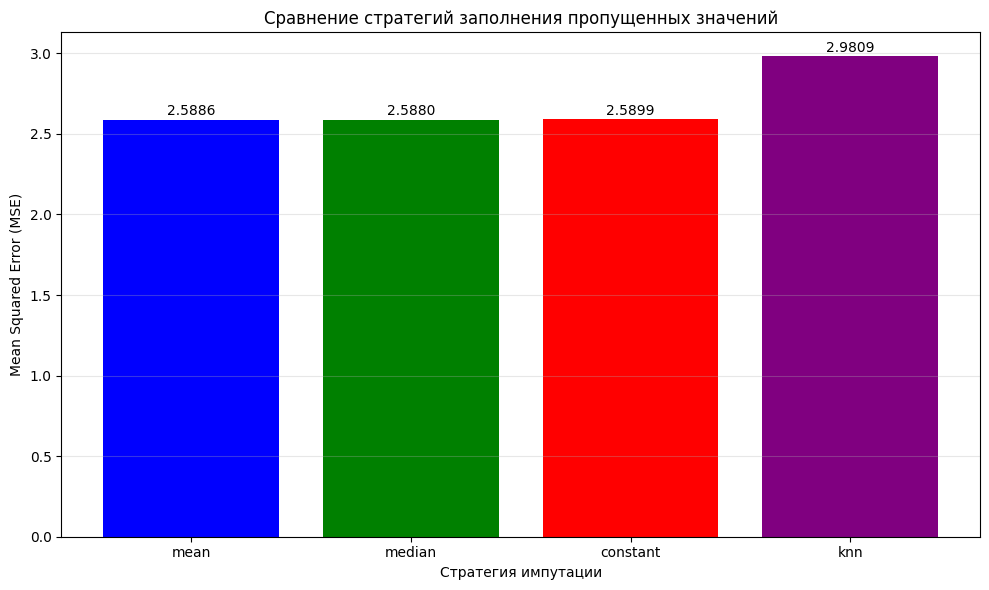


Процент пропущенных значений: 20.1%
Количество пропусков: 4028 из 20000

Пример импутации (первые 10 строк):
ДО импутации:
         X1        X2
0       NaN -0.138264
1  0.647689  1.523030
2 -0.234153       NaN
3       NaN  0.767435
4 -0.469474  0.542560
5 -0.463418 -0.465730
6  0.241962 -1.913280
7 -1.724918 -0.562288
8       NaN  0.314247
9 -0.908024 -1.412304

ПОСЛЕ импутации (стратегия 'mean'):
         X1        X2
0  0.006863 -0.138264
1  0.647689  1.523030
2 -0.234153  0.005497
3  0.006863  0.767435
4 -0.469474  0.542560
5 -0.463418 -0.465730
6  0.241962 -1.913280
7 -1.724918 -0.562288
8  0.006863  0.314247
9 -0.908024 -1.412304


In [15]:
# Визуализируем результаты
plt.figure(figsize=(10, 6))
strategies_list = list(results.keys())
mse_values = list(results.values())

bars = plt.bar(strategies_list, mse_values, color=['blue', 'green', 'red', 'purple'])
plt.xlabel('Стратегия импутации')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Сравнение стратегий заполнения пропущенных значений')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars, mse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Покажем процент пропусков
print(f"\nПроцент пропущенных значений: {(np.isnan(X_missing).sum() / X_missing.size * 100):.1f}%")
print(f"Количество пропусков: {np.isnan(X_missing).sum()} из {X_missing.size}")

# Покажем как выглядят импутированные значения для первой стратегии
imputer_mean = SimpleImputer(strategy='mean')
X_imputed_mean = imputer_mean.fit_transform(X_missing)

print("\nПример импутации (первые 10 строк):")
print("ДО импутации:")
print(pd.DataFrame(X_missing[:10], columns=['X1', 'X2']))
print("\nПОСЛЕ импутации (стратегия 'mean'):")
print(pd.DataFrame(X_imputed_mean[:10], columns=['X1', 'X2']))

Выводы:

1. Простое удаление может привести к потере информации
2. Среднее/медиана работают хорошо при нормальном распределении (как вы думаете почему?)
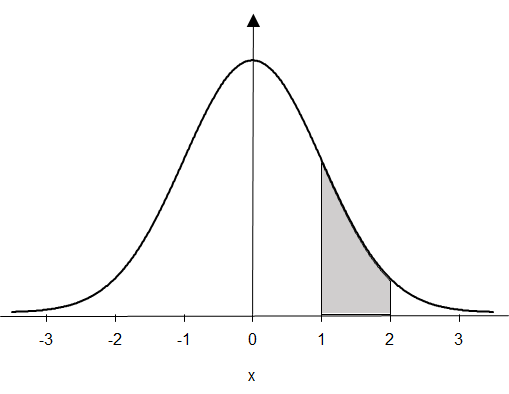
3. KNN лучше сохраняет структуру данных (каково ваше мнение? С чем это может быть связано?) Более подробно этот метод будет рассмотрен в другой лекции


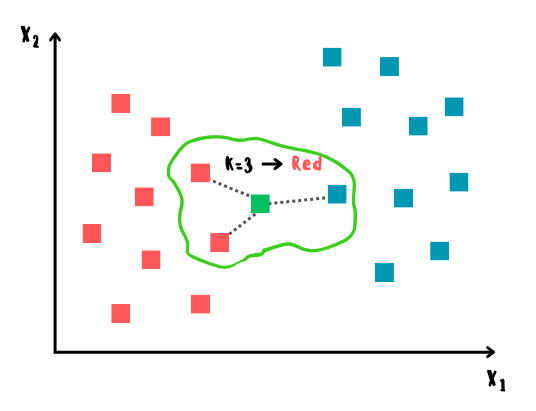

4. Всегда важно понять причину пропусков

## Выводы
Типы пропусков в датасете:
  1. MCAR (Missing Completely At Random) - случайные пропуски
     - Пример: случайные пропуски в age, gender, math_score
     - Можно удалять или заполнять простыми методами
  
  2. MAR (Missing At Random) - пропуски, зависящие от других переменных
     - Пример: пропуски в GPA у студентов с низкой успеваемостью
     - Лучше использовать групповые методы или KNN
  
  3. MNAR (Missing Not At Random) - систематические пропуски
     - Пример: пропуски в attendance у работающих студентов
     - Требуют специального подхода

## Рекомендации по выбору стратегии:
**Удаление строк:**

     * Использовать при < 5% пропусков
     * Использовать для колонок с > 30% пропусков

**Заполнение средним/медианой:**

     * Для нормально распределенных данных
     * Медиана лучше при наличии выбросов

**Групповое заполнение:**

     * Когда есть логические группы (факультеты, курсы)
     * Лучше сохраняет структуру данных

**KNN импутация:**

     * Когда есть сильные корреляции между признаками
     * Лучший метод для сложных зависимостей

# Работа с дубликатами

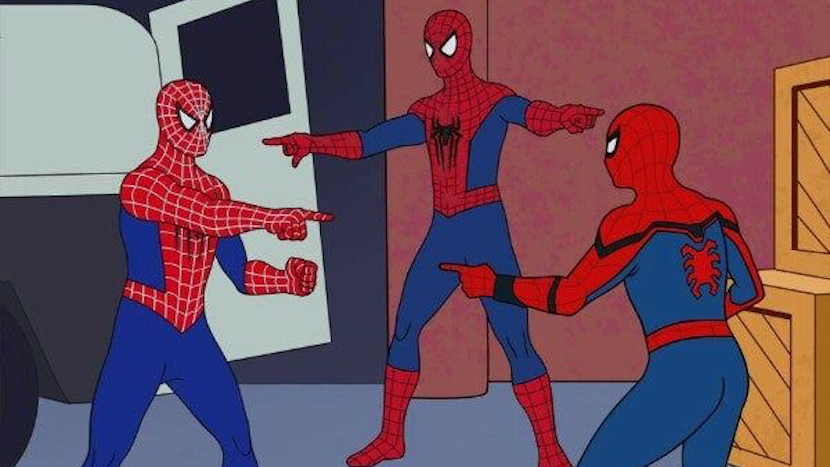

## Анализ дубликатов

In [ ]:
# Находим все дубликаты
data = pd.read_csv("/content/students_two.csv")
duplicates = data[data.duplicated(keep=False)]

print(f"Всего дублирующихся строк: {len(duplicates)}")

Всего дублирующихся строк: 199


Дубликаты по отдельным колонкам

In [ ]:
for col in data.columns:
    dup_count = data.duplicated(subset=[col]).sum()

    if dup_count > 0:
        print(f"{col}: {dup_count} дубликатов ({dup_count/len(data)*100:.1f}%)")

student_id: 179 дубликатов (7.9%)
faculty: 2259 дубликатов (99.5%)
year: 2265 дубликатов (99.8%)
gender: 2267 дубликатов (99.9%)
age: 2256 дубликатов (99.4%)
gpa: 2188 дубликатов (96.4%)
math_score: 2239 дубликатов (98.6%)
language_score: 2240 дубликатов (98.7%)
science_score: 2240 дубликатов (98.7%)
humanities_score: 2241 дубликатов (98.7%)
attendance: 1866 дубликатов (82.2%)
study_hours: 2240 дубликатов (98.7%)
part_time_work: 2267 дубликатов (99.9%)
scholarship: 2267 дубликатов (99.9%)
loan: 2267 дубликатов (99.9%)
sports: 2267 дубликатов (99.9%)
clubs: 2265 дубликатов (99.8%)
parent_education: 2260 дубликатов (99.6%)
income_level: 2258 дубликатов (99.5%)
distance_to_university: 1785 дубликатов (78.6%)
final_grade: 2209 дубликатов (97.3%)


## Удаление полных дубликатов

In [ ]:
df_no_duplicates = data.drop_duplicates()
print(f"Размер до удаления: {len(data)}")
print(f"Размер после удаления: {len(df_no_duplicates)}")
print(f"Удалено дубликатов: {len(data) - len(df_no_duplicates)}")

Размер до удаления: 2270
Размер после удаления: 2170
Удалено дубликатов: 100


## Удаление дубликатов по ключевым полям

In [ ]:
# Определяем ключевые поля
key_cols = ['faculty', 'year', 'gender', 'age', 'gpa']
df_no_key_duplicates = data.drop_duplicates(subset=key_cols)

print(f"Ключевые поля: {key_cols}")
print(f"Размер до удаления: {len(data)}")
print(f"Размер после удаления: {len(df_no_key_duplicates)}")
print(f"Удалено дубликатов: {len(data) - len(df_no_key_duplicates)}")

Ключевые поля: ['faculty', 'year', 'gender', 'age', 'gpa']
Размер до удаления: 2270
Размер после удаления: 1570
Удалено дубликатов: 700


Агрегация дубликатов

**Агрегация дубликатов** — это процесс объединения нескольких похожих записей в одну, путем вычисления обобщающих статистик (среднее, медиана, сумма и т.д.) для числовых полей.

Представьте, что у вас есть данные об успеваемости студентов, и один и тот же студент по ошибке записан несколько раз:

| Студент | Курс | GPA | Посещаемость |
|-------------|-------------|-------------|-------------|
| Иванов И.   | 2    | 4.2    |   85%          |
| Иванов И.   | 2    | 4.3    |   87%          |
| Иванов И.   | 2    | 4.1    |   84%          |



Вместо того чтобы хранить 3 записи, мы можем агрегировать их в одну:


| Студент |	Курс |	GPA (среднее) |	Посещаемость (среднее) |
|---------|------|----------------|------------------------|
|Иванов И. | 2 | 4.2 |  85.3%  |



In [ ]:
#Определяем ключевые поля - по ним мы будем группировать записи
key_cols = ['faculty', 'year', 'gender', 'age', 'gpa']

In [ ]:
# Группируем по ключевым полям и агрегируем
df_aggregated = df.groupby(key_cols).agg({
    'final_grade': 'mean', # Средняя итоговая оценка
    'attendance': 'mean',  # Средняя посещаемость
    'study_hours': 'mean' # Среднее количество часов
}).reset_index()

print(f"  Размер после агрегации: {len(df_aggregated)}")

  Размер после агрегации: 1386


## Рекомендации по работе с дубликатами:

Полные дубликаты:

     * Всегда удалять
  
Частичные дубликаты:

     * Анализировать причину
     * Можно агрегировать или удалять
  
Дубликаты по ключевым полям:

     * Проверять, не являются ли разными записями одного студента
     * Использовать агрегацию

# Выбросы

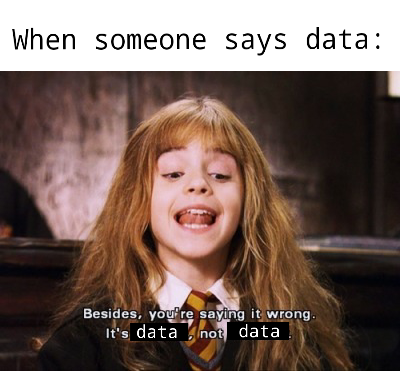

In [ ]:
# Загружаем датасет
df = pd.read_csv('students_with_errors.csv', encoding='utf-8-sig')

In [ ]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"Колонки: {list(df.columns)}")

Размер датасета: 2270 строк, 21 колонок
Колонки: ['student_id', 'faculty', 'year', 'gender', 'age', 'gpa', 'math_score', 'language_score', 'science_score', 'humanities_score', 'attendance', 'study_hours', 'part_time_work', 'scholarship', 'loan', 'sports', 'clubs', 'parent_education', 'income_level', 'distance_to_university', 'final_grade']


### ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

### АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ

In [ ]:
print("Типы данных:")
print(df.dtypes)



Типы данных:
student_id                 object
faculty                    object
year                      float64
gender                     object
age                        object
gpa                        object
math_score                 object
language_score            float64
science_score             float64
humanities_score          float64
attendance                float64
study_hours                object
part_time_work             object
scholarship                object
loan                       object
sports                     object
clubs                      object
parent_education           object
income_level               object
distance_to_university    float64
final_grade                object
dtype: object


In [ ]:
print("Статистика по числовым колонкам:")
print(df.describe())

Статистика по числовым колонкам:
              year  language_score  science_score  humanities_score  \
count  2255.000000     2207.000000    2207.000000       2207.000000   
mean      2.330377        3.397417       3.388446          3.390757   
std       1.075019        0.761808       0.555470          0.614833   
min       1.000000       -5.000000      -3.000000         -3.000000   
25%       1.000000        3.000000       3.000000          3.100000   
50%       2.000000        3.400000       3.400000          3.400000   
75%       3.000000        3.800000       3.700000          3.700000   
max       4.000000       15.000000      10.000000         15.000000   

        attendance  distance_to_university  
count  2164.000000             2253.000000  
mean      0.793723               25.200488  
std       0.244174               20.916654  
min      -0.500000             -100.000000  
25%       0.719000               13.200000  
50%       0.782500               25.500000  
75%       0.

Анализ факультетов

In [ ]:
faculty_counts = df['faculty'].value_counts()

print(f"Уникальных значений: {len(faculty_counts)}")
print(f"Топ-10 факультетов:")
print(faculty_counts.head(10))

Уникальных значений: 31
Топ-10 факультетов:
faculty
CS             392
Economics      306
Psychology     257
Mathematics    229
Law            226
Biology        224
Physics        205
Languages      141
Chemistry      132
History        116
Name: count, dtype: int64


In [ ]:
print(df['faculty'].unique())

['Economics' 'Physics' 'CS' 'Law' 'biology' 'Languages' 'Mathematics'
 'Biology' 'History' 'Psychology' 'Chemistry' 'психология' 'биология' nan
 'юриспруденция' 'C.S.' 'Bio' 'Math' 'КомпНаук' 'physics' 'математика'
 'история' 'Hist' 'economics' 'Phys' 'computer science' 'LAW'
 'Computer Science' 'psychology' 'law' 'физика' 'CompSci']


In [ ]:
valid_faculties = ['CS', 'Mathematics', 'Physics', 'Biology', 'Chemistry',
                   'Economics', 'Psychology', 'Law', 'History', 'Languages']


In [ ]:
invalid_faculties = df[~df['faculty'].isin(valid_faculties)]['faculty'].unique()
print(f"Некорректные написания факультетов ({len(invalid_faculties)}):")
print(invalid_faculties[:20])

Некорректные написания факультетов (22):
['biology' 'психология' 'биология' nan 'юриспруденция' 'C.S.' 'Bio' 'Math'
 'КомпНаук' 'physics' 'математика' 'история' 'Hist' 'economics' 'Phys'
 'computer science' 'LAW' 'Computer Science' 'psychology' 'law']


Анализ пола

In [ ]:
gender_counts = df['gender'].value_counts()

print(f"Уникальных значений: {len(gender_counts)}")
print(gender_counts)

Уникальных значений: 14
gender
Female     1108
Male       1077
Женский       5
муж           4
female        3
male          3
MALE          2
Man           2
Мужской       2
Woman         1
M             1
жен           1
FEMALE        1
F             1
Name: count, dtype: int64


In [ ]:
valid_genders = ['Male', 'Female']
invalid_genders = df[~df['gender'].isin(valid_genders)]['gender'].unique()

print(f"Некорректные написания пола ({len(invalid_genders)}):")
print(f"{invalid_genders}")

Некорректные написания пола (13):
[nan 'муж' 'Женский' 'female' 'MALE' 'Woman' 'Man' 'жен' 'M' 'Мужской'
 'male' 'FEMALE' 'F']


Анализ образования родителей

In [ ]:
edu_counts = df['parent_education'].value_counts()
print(f"  Уникальных значений: {len(edu_counts)}")
print(edu_counts.head(15))



  Уникальных значений: 25
parent_education
Bachelor             804
Master               568
College              407
School               230
PhD                  224
бакалавр               5
Магистр                4
College education      3
bachelor               3
колледж                2
среднее                2
Колледж                2
Bachewor               1
dollege                1
Bjchelor               1
Name: count, dtype: int64


In [ ]:
valid_edu = ['School', 'College', 'Bachelor', 'Master', 'PhD']
invalid_edu = df[~df['parent_education'].isin(valid_edu)]['parent_education'].unique()

print(f"Некорректные написания образования ({len(invalid_edu)})")
print(invalid_edu[:20])

Некорректные написания образования (21)
['колледж' nan 'Bachewor' 'среднее' 'бакалавр' 'Магистр'
 'College education' 'dollege' 'bachelor' 'Bjchelor' 'Колледж' 'Mastxr'
 'магистр' 'доктор наук' 'Bachelor degree' 'school' 'Среднее' 'phd'
 'School education' 'Master degree']


Анализ дохода

In [ ]:
income_counts = df['income_level'].value_counts()
print(f"Уникальных значений: {len(income_counts)}")
print(income_counts.head(10))


Уникальных значений: 22
income_level
High             972
Medium           801
Low              423
Medium income      5
high               4
High income        4
Средний            3
Высокий            2
Низкий             2
высокий            2
Name: count, dtype: int64


In [ ]:
valid_income = ['Low', 'Medium', 'High']
invalid_income = df[~df['income_level'].isin(valid_income)]['income_level'].unique()

print(f"Некорректные написания дохода ({len(invalid_income)}):")
print(f"{invalid_income[:20]}")

Некорректные написания дохода (20):
[nan 'medium' 'Средний' 'Medium income' 'oigh' 'High income' 'high'
 'Низкий' 'высокий' 'cigh' 'Lcw' 'low' 'Высокий' 'Medtum' 'Meduum'
 'Medikm' 'средний' 'низкий' 'Hiih' 'Mediuv']
